In [1]:
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from deep_isochron.model.invertible import (
    AbstractInvertibleTransform,
    AffineCoupling,
    BiLipschitzLinear,
    InvertibleLinear,
    MonotonicRQCoupling,
    SequentialINN,
)
from deep_isochron.model.latent_dynamics import (
    AbstractLatentDynamics,
    HopfNormalForm,
)
from deep_isochron.systems.base import AbstractODE
from deep_isochron.systems.fitzhugh_nagumo import FitzhughNagumo
from deep_isochron.systems.normal_forms import BautinNormalForm, HopfNormalForm
from deep_isochron.training import (
    RandomSampleBatching,
    SegmentLoader,
    TimeSeriesDataset,
    VanillaTrainer,
)
from jaxtyping import Array, Float, PRNGKeyArray


jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_device", jax.devices("gpu")[1])


In [2]:
normal_form = HopfNormalForm(a=1.0, w=10.0, w0=0.1)

normal_form2 = BautinNormalForm(a=1.0, b=0.5, w=10.0, w0=0.1)

In [3]:
normal_form.w0

Array(0.1, dtype=float64, weak_type=True)

In [4]:
ts = jnp.arange(0, 20.0, 0.01)
y0 = jax.random.uniform(jax.random.key(0), shape=(normal_form.dim,))

In [5]:
def cartesian_to_polar(xy):
    x, y = xy
    return jnp.stack((jnp.hypot(x, y), jnp.arctan2(y, x)))


def polar_to_cartesian(rtheta):
    r, theta = rtheta
    return jnp.stack((r * jnp.cos(theta), r * jnp.sin(theta)))

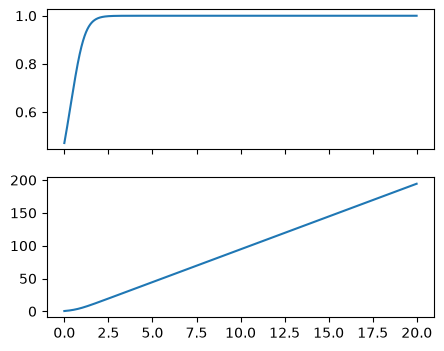

In [6]:
traj = normal_form2.solve(ts, cartesian_to_polar(y0))
fig, axes = plt.subplots(2, 1, figsize=(5, 4), sharex=True)
axes[0].plot(ts, traj[:, 0])
axes[1].plot(ts, traj[:, 1])

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharex=True, sharey=True)
for ax, nf in zip(axes, (normal_form, normal_form2)):
    traj = nf.solve(ts, cartesian_to_polar(y0))
    ax.plot(*polar_to_cartesian(traj.T))

In [ ]:
class LatentDynamicsConverter(eqx.Module):
    latent_dynamics: AbstractLatentDynamics | AbstractODE
    bijection: AbstractInvertibleTransform

    def __init__(
        self,
        latent_dynamics: AbstractLatentDynamics | AbstractODE,
        bijection: AbstractInvertibleTransform,
    ):
        self.latent_dynamics = latent_dynamics
        self.bijection = bijection

    @property
    def dim(self) -> int:
        return self.latent_dynamics.dim

    def __call__(
        self,
        ts: Float[Array, " time"],
        x0: Float[Array, " obs_dim"],
        return_latent_trajectory: bool = True,
    ) -> tuple[Float[Array, "time obs_dim"], Float[Array, "time latent_dim"] | None]:
        y0: Float[Array, " latent_dim"] = self.bijection(x0)
        y0_polar = cartesian_to_polar(y0)
        yt_polar: Float[Array, "time latent_dim"] = self.latent_dynamics.solve(
            ts, y0_polar, max_steps=8192, atol=1e-6, rtol=1e-4, solver=dfx.Kvaerno5()
        )
        yt = jax.vmap(polar_to_cartesian)(yt_polar)
        xt: Float[Array, "time obs_dim"] = eqx.filter_vmap(self.bijection.inverse)(yt)

        if return_latent_trajectory:
            return xt, yt
        else:
            return xt, None


In [ ]:
def make_invertible_block(key: PRNGKeyArray):
    key_l, key_c = jax.random.split(key)
    linear = InvertibleLinear(dim=2, key=key_l)
    # linear = BiLipschitzLinear(dim=2, max_lipschitz=2.0, key=key_l)
    coupling = MonotonicRQCoupling(
        dim=2,
        width_hidden=32,
        num_knots=10,
        xy_range=(-4, 4),
        key=key_c,
    )
    return (linear, coupling)


num_blocks = 7
autoencoder = LatentDynamicsConverter(
    latent_dynamics=BautinNormalForm(
        a=1.0, b=0.5, w=-2 * jnp.pi / 10.0, w0=2 * jnp.pi / 10.0
    ),
    bijection=SequentialINN(
        sum(
            (make_invertible_block(jax.random.key(k)) for k in range(num_blocks)),
            start=(),
        )
    ),
)

In [ ]:
def make_invertible_block(key: PRNGKeyArray):
    key_l, key_c = jax.random.split(key)
    # linear = InvertibleLinear(dim=2, key=key_l)
    linear = BiLipschitzLinear(dim=2, max_lipschitz=2.0, key=key_l)
    coupling = AffineCoupling(
        dim=2,
        width_hidden=32,
        affine_clamping=3.0,
        key=key_c,
    )
    return (linear, coupling)


num_blocks = 7
autoencoder = LatentDynamicsConverter(
    latent_dynamics=BautinNormalForm(
        a=1.0, b=0.5, w=-2 * jnp.pi / 10.0, w0=2 * jnp.pi / 10.0
    ),
    bijection=SequentialINN(
        sum(
            (make_invertible_block(jax.random.key(k)) for k in range(num_blocks)),
            start=(),
        )
    ),
)

## Generate data for Fitahugh-Nagumo

In [10]:
ode = FitzhughNagumo()

u0 = jnp.asarray([1.0, 0.0])
t = jnp.linspace(0, 100, 1000)
sol = dfx.diffeqsolve(
    dfx.ODETerm(ode.rhs),
    dfx.Tsit5(),
    t[0],
    t[-1],
    None,
    u0,
    stepsize_controller=dfx.PIDController(rtol=1e-6, atol=1e-6),
    saveat=dfx.SaveAt(ts=t),
)

In [11]:
n_trajs = 1000
t_end = 20
t = jnp.arange(0, t_end + 0.01, 0.01)


def solve_single(
    ode,
    ts: Float[Array, " time"],
    u0: Float[Array, " dim"],
    rtol: float = 1e-8,
    atol: float = 1e-10,
    solver: dfx.AbstractSolver = dfx.Tsit5(),
):
    sol: dfx.Solution = dfx.diffeqsolve(
        dfx.ODETerm(ode.rhs),
        solver,
        ts[0],
        ts[-1],
        None,
        u0,
        stepsize_controller=dfx.PIDController(rtol=rtol, atol=atol),
        saveat=dfx.SaveAt(ts=t),
    )
    return sol.ys


u0_train = jax.random.uniform(
    jax.random.key(0), (n_trajs, ode.dim), minval=-3, maxval=3
)
u_train = eqx.filter_vmap(solve_single, in_axes=(None, None, 0))(ode, t, u0_train)
print(u_train.shape)

(1000, 2002, 2)


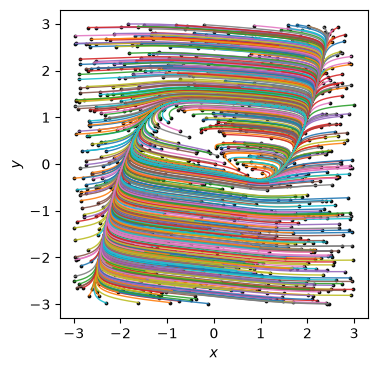

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for i in range(0, len(u_train)):
    ax.plot(*u_train[i].T, alpha=0.9, linewidth=1.0)
ax.scatter(*u_train[:, 0].T, s=3, color="black", alpha=0.9)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_aspect("equal")

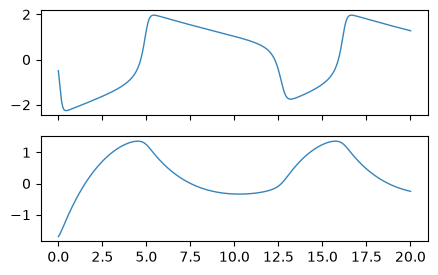

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(5, 3), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t, u_train[0, :, i], alpha=0.9, linewidth=1.0)

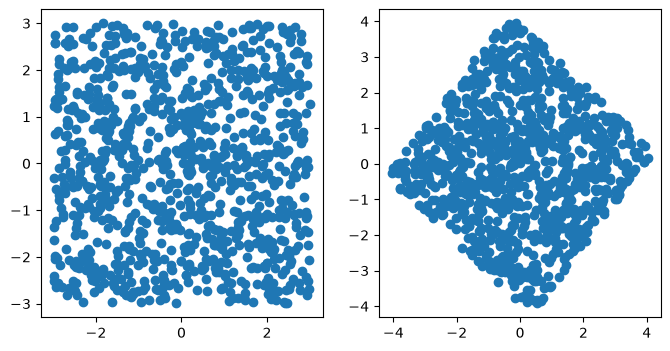

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].scatter(*u_train[:, 0].T)
axes[1].scatter(*eqx.filter_vmap(autoencoder.bijection)(u_train[:, 0]).T)

In [15]:
u_train.shape

(1000, 2002, 2)

In [16]:
u_pred, y_pred = eqx.filter_vmap(autoencoder, in_axes=(None, 0))(t, u_train[:, 0])
u_pred.shape

(1000, 2002, 2)

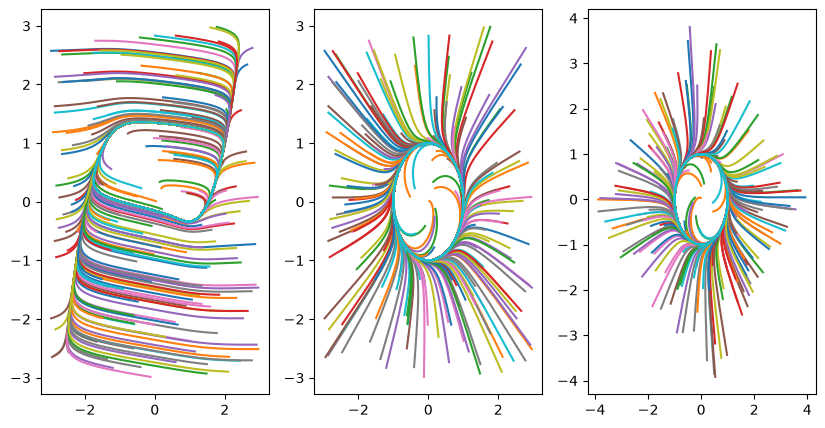

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
for i in range(0, len(u_pred), 5):
    axes[0].plot(*u_train[i].T)
    axes[1].plot(*u_pred[i].T)
    axes[2].plot(*y_pred[i].T)

In [18]:
u_train_ae = eqx.filter_vmap(
    lambda x: autoencoder.bijection.inverse(autoencoder.bijection(x))
)(u_train[:, 0])
jnp.max(jnp.abs(u_train[:, 0] - u_train_ae))

Array(2.22044605e-15, dtype=float64)

In [19]:
def loss_inn(model: LatentDynamicsConverter, batch, args=None):
    t_batch: Float[Array, "batch time"]
    x_batch: Float[Array, "batch time dim"]
    t_batch, x_batch = batch
    x_pred, y_pred = eqx.filter_vmap(model)(t_batch, x_batch[:, 0])
    # y_pred: Float[Array, "batch time latent_dim"] = eqx.filter_vmap(
    #     lambda t, x0: model.latent_dynamics(t, model.encoder(x0))
    # )(t_batch, x_batch[:, 0])
    # # x_pred: Float[Array, "batch time dim"] = eqx.filter_vmap(model)(
    # #     t_batch, x_batch[:, 0]
    # # )
    # x_pred = jax.vmap(jax.vmap(model.decoder))(y_pred)
    mse = jnp.mean((x_batch - x_pred) ** 2)

    y_batch = jax.vmap(jax.vmap(model.bijection))(x_batch)
    mse_latent = jnp.mean((y_batch - y_pred) ** 2)

    # x_ae = jax.vmap(jax.vmap(model.decoder))(y_batch)
    # y_ae = jax.vmap(jax.vmap(model.encoder))(x_ae)
    # loss_identity = jnp.mean((x_batch - x_ae) ** 2)
    # loss_identity_latent = jnp.mean((y_batch - y_ae) ** 2)

    # Weighting the latent space mse by 0
    return mse + mse_latent, {
        "mse": mse,
        # "identity_loss": loss_identity,
        # "identity_latent_loss": loss_identity_latent,
        "mse_latent": mse_latent,
    }

In [20]:
dataset = TimeSeriesDataset(t, u_train)
loader = SegmentLoader(
    dataset,
    segment_length=100,
    batch_strategy=RandomSampleBatching(batch_size=2048),
)
loader_state = loader.init()
batch, loader_state = loader.load_batch(loader_state)

In [21]:
t[:100]

Array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99], dtype=float64)

In [22]:
batch[1].shape

(2048, 100, 2)

In [23]:
batch[0].shape

(2048, 100)

In [24]:
batch_pred = eqx.filter_vmap(autoencoder)(batch[0], batch[1][:, 0])[0]

In [25]:
batch_pred.shape

(2048, 100, 2)

In [26]:
batch_pred[i].shape

(100, 2)

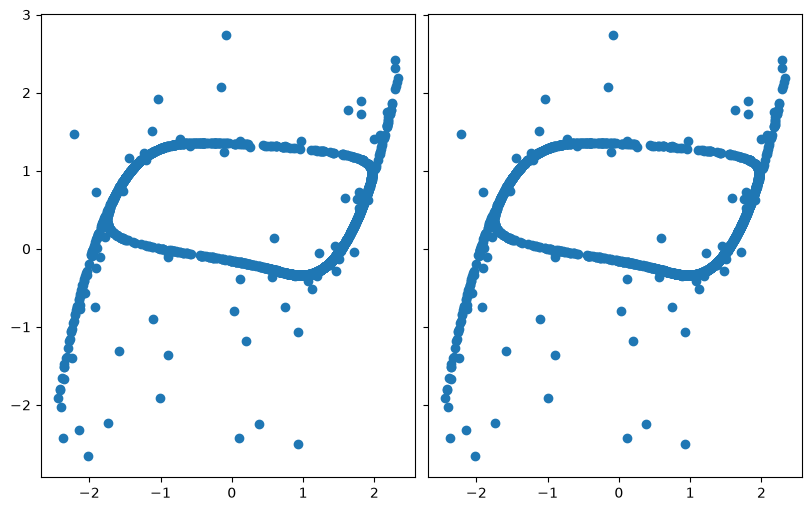

In [27]:
fig, axes = plt.subplots(
    1, 2, figsize=(8, 5), constrained_layout=True, sharex=True, sharey=True
)

axes[0].scatter(*batch[1][:, 0].T)
axes[1].scatter(*batch_pred[:, 0].T)

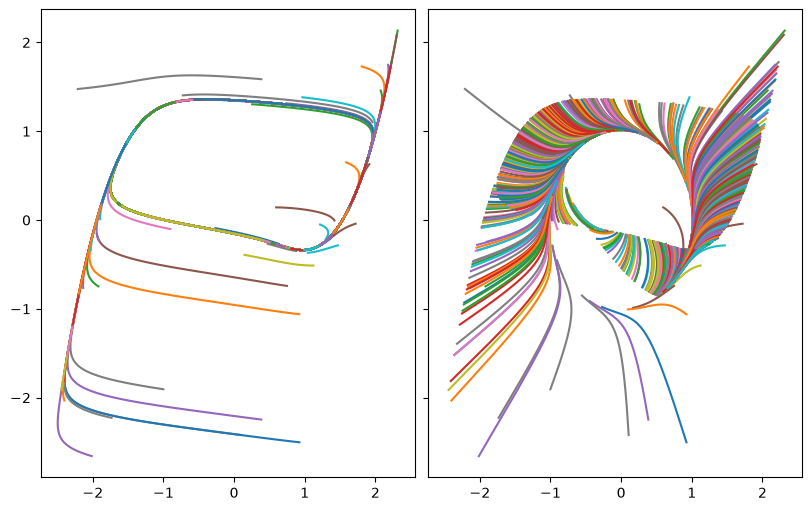

In [28]:
fig, axes = plt.subplots(
    1, 2, figsize=(8, 5), constrained_layout=True, sharex=True, sharey=True
)
for i in range(0, len(batch[1]), 2):
    axes[0].plot(*batch[1][i].T)
    axes[1].plot(*batch_pred[i].T)
# axes[0].set_xlim((-3.5, 3.5))
# axes[0].set_ylim((-3.5, 3.5))

In [29]:
trainer = VanillaTrainer(
    optax.adamw(learning_rate=1e-3),
    max_epochs=2000,
    wandb_entity="jhko725",
    wandb_project="isochron",
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jhko725/.netrc.
wandb: Currently logged in as: jhko725 (jhelab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [30]:
model_trained, loss_history = trainer.train(
    autoencoder, loss_inn, train_loader=loader, config={"model": []}
)

step=0, loss=Array(0.52506497, dtype=float64)
step=1, loss=Array(0.32705728, dtype=float64)
step=2, loss=Array(0.24641226, dtype=float64)
step=3, loss=Array(0.21571332, dtype=float64)
step=4, loss=Array(0.20468813, dtype=float64)
step=5, loss=Array(0.18473434, dtype=float64)
step=6, loss=Array(0.17537625, dtype=float64)
step=7, loss=Array(0.15471057, dtype=float64)
step=8, loss=Array(0.1394898, dtype=float64)
step=9, loss=Array(0.1176543, dtype=float64)
step=10, loss=Array(0.1123968, dtype=float64)
step=11, loss=Array(0.10093306, dtype=float64)
step=12, loss=Array(0.10361125, dtype=float64)
step=13, loss=Array(0.11650653, dtype=float64)
step=14, loss=Array(0.10544828, dtype=float64)
step=15, loss=Array(0.10461181, dtype=float64)
step=16, loss=Array(0.10127115, dtype=float64)
step=17, loss=Array(0.08543811, dtype=float64)
step=18, loss=Array(0.0875992, dtype=float64)
step=19, loss=Array(0.08136055, dtype=float64)
step=20, loss=Array(0.08781187, dtype=float64)
step=21, loss=Array(0.08760

loss_train,█▇▆▅▄▂▂▁▂▁▁▂▁▂▁▁▁▁▁▅▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mse_latent_train,█▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mse_train,▇▆▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁█▇▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss_train,0.00095
mse_latent_train,0.00024
mse_train,0.0007


In [31]:
t_subset, u_train_subset = dataset.t[::10, ::5], dataset.u[::10, ::5]  # batch
u_pred_subset, w_pred_subset = eqx.filter_vmap(model_trained)(
    t_subset, u_train_subset[:, 0]
)

t_longer = jnp.arange(
    t_subset[0, 0], 4 * t_subset[0, -1], t_subset[0, 1] - t_subset[0, 0]
)
u_longer = eqx.filter_vmap(model_trained, in_axes=(None, 0))(
    t_longer, u_train_subset[:, 0]
)[0]

In [32]:
model_trained.latent_dynamics.period()

Array(11.37465833, dtype=float64)

In [33]:
model_trained.latent_dynamics.eigenvalues_origin()

Array([0.59284942+0.64077593j, 0.59284942-0.64077593j], dtype=complex128)

In [34]:
model_trained.latent_dynamics.a

Array(0.59284942, dtype=float64)

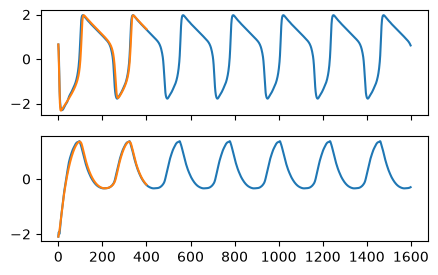

In [35]:
traj_idx = 50
fig, axes = plt.subplots(2, 1, figsize=(5, 3), sharex=True)
for i, ax in enumerate(axes):
    # ax.plot(u_pred_subset[traj_idx, :, i], "--")
    ax.plot(u_longer[traj_idx, :, i])
    ax.plot(u_train_subset[traj_idx, :, i])

# ax.set_xlim((1500,2000))

Text(0.5, 1.0, 'Model latent space')

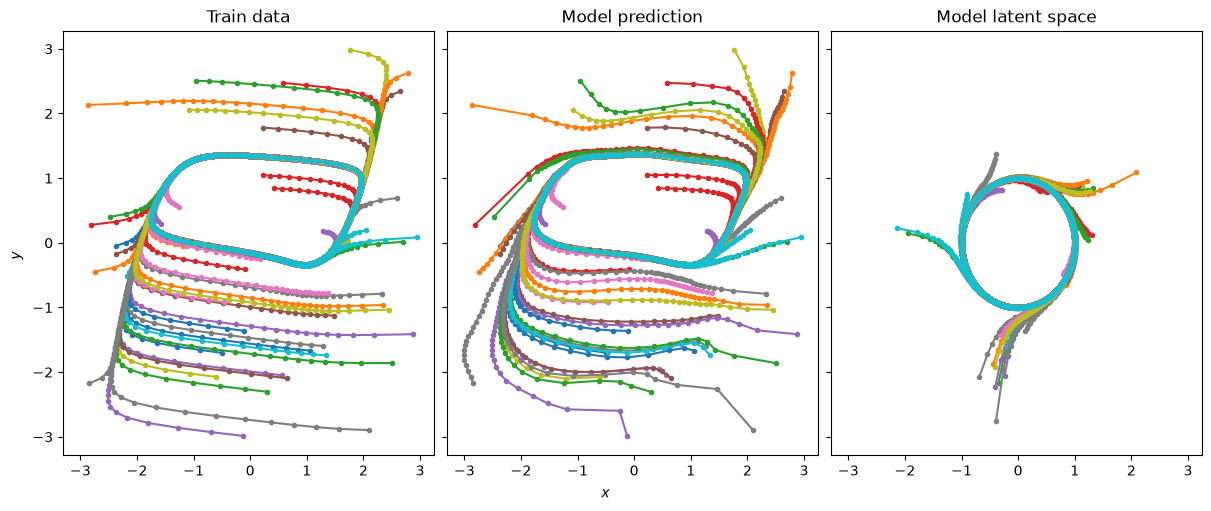

In [36]:
fig, axes = plt.subplots(
    1, 3, figsize=(12, 5), constrained_layout=True, sharex=True, sharey=True
)
for i in range(0, len(u_train_subset), 2):
    axes[0].plot(*u_train_subset[i].T, ".-")
    axes[1].plot(*u_pred_subset[i].T, ".-")
    axes[2].plot(*w_pred_subset[i].T, ".-")
# axes[0].set_xlim((-3.5, 3.5))
# axes[0].set_ylim((-3.5, 3.5))
fig.supxlabel("$x$", fontsize="medium")
fig.supylabel("$y$", fontsize="medium")
axes[0].set_title("Train data")
axes[1].set_title("Model prediction")
axes[2].set_title("Model latent space")

In [37]:
u_train_ae = eqx.filter_vmap(
    lambda x: model_trained.bijection.inverse(model_trained.bijection(x))
)(u_train[:, 0])
jnp.max(jnp.abs(u_train[:, 0] - u_train_ae))

Array(1.54432023e-13, dtype=float64)

In [38]:
xy_grid = jnp.stack(
    jnp.meshgrid(jnp.linspace(-3, 3, 50), jnp.linspace(-3, 3, 50)), axis=-1
)
xy_grid.shape

(50, 50, 2)

In [39]:
from einops import rearrange


def bijection_err(bijection, x):
    x_ = bijection.inverse(bijection(x))
    return jnp.linalg.norm(x - x_)


biject_err = eqx.filter_vmap(bijection_err, in_axes=(None, 0))(
    model_trained.bijection, rearrange(xy_grid, "X Y C-> (X Y) C")
)

In [40]:
biject_err.shape

(2500,)

In [41]:
jnp.max(biject_err)

Array(2.27547975e-13, dtype=float64)

In [42]:
biject_err = rearrange(biject_err, "(X Y) -> X Y", X=xy_grid.shape[0])

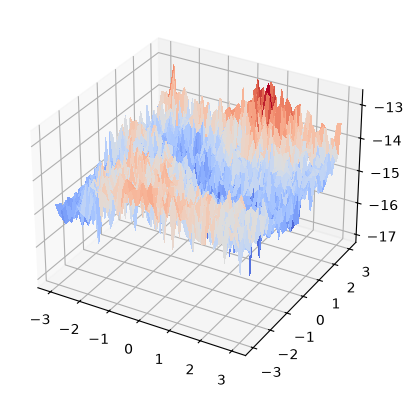

In [43]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
# Plot the surface.
surf = ax.plot_surface(
    xy_grid[..., 0],
    xy_grid[..., 1],
    jnp.log10(biject_err),
    cmap="coolwarm",
    linewidth=0,
    antialiased=False,
)